# Monte Carlo-integrasjon

Denne notebooken forbereder dere til **Øving 2, oppgave 7**, hvor dere skal bruke Monte Carlo-integrasjon til å regne ut et areal og et volum. Vi bygger opp metoden fra bunnen, helt enkelt, i noen få steg.

## Ideen bak Monte Carlo-integrasjon

Monte Carlo-integrasjon er en metode for å *tilnærme* et integral ved hjelp av tilfeldige tall, i stedet for å regne det ut eksakt (som med Sympy) eller med et fast rutenett (som med Scipy sin `quad`/`dblquad`).

Ideen for å regne ut et areal $\iint_D 1\, dA$ er enkel:

1. Legg området $D$ inni en enkel boks $B$ (et rektangel) som vi vet arealet til.
2. Trekk mange tilfeldige punkter jevnt fordelt i $B$, og tell hvor mange som havner inni $D$.
3. Andelen "treff" ganger arealet til $B$ gir et estimat for arealet til $D$:

$$ \text{Areal}(D) \approx \text{Areal}(B) \cdot \frac{\text{antall treff}}{\text{antall forsøk}} $$

Jo flere punkter vi bruker, jo bedre blir estimatet -- men det koster mer regnetid.

## Eksempel: arealet av en enhetsdisk

La oss teste metoden på et kjent eksempel: en disk (sirkelskive) med radius $1$ sentrert i origo. Vi vet at arealet er $\pi \cdot 1^2 = \pi \approx 3.14159$.

Vi legger disken inni boksen $B=[-1,1]\times[-1,1]$, som har areal $4$.

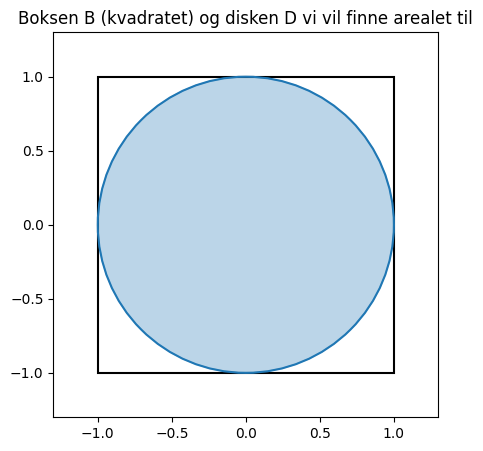

In [8]:
%matplotlib inline
import matplotlib.pyplot as plt

fig, ax = plt.subplots(figsize=(5,5))

# Boksen B = [-1,1] x [-1,1]
ax.add_patch(plt.Rectangle((-1,-1), 2, 2, fill=False, color="black", linewidth=1.5))

# Enhetsdisken D: x^2 + y^2 <= 1
ax.add_patch(plt.Circle((0,0), 1, fill=True, color="tab:blue", alpha=0.3))
ax.add_patch(plt.Circle((0,0), 1, fill=False, color="tab:blue", linewidth=1.5))

ax.set_xlim(-1.3, 1.3)
ax.set_ylim(-1.3, 1.3)
ax.set_aspect('equal')
ax.set_title("Boksen B (kvadratet) og disken D vi vil finne arealet til")
plt.show()

Estimert areal: 2.96
Eksakt areal (pi): 3.141592653589793


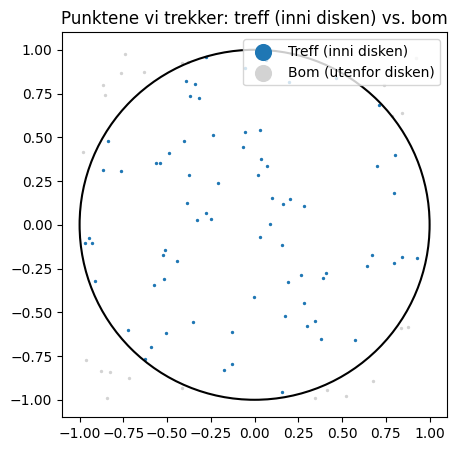

In [10]:
%matplotlib inline
import random as rnd
import matplotlib.pyplot as plt

# Boksen B = [-1,1] x [-1,1]
xmin, xmax = -1.0, 1.0
ymin, ymax = -1.0, 1.0

numSim = 100
numHit = 0

xs_hit, ys_hit = [], []     # punktene som havner INNI disken (treff)
xs_miss, ys_miss = [], []   # punktene som havner UTENFOR disken (bom)

for i in range(numSim):
    x = rnd.random() * (xmax - xmin) + xmin
    y = rnd.random() * (ymax - ymin) + ymin
    if x*x + y*y < 1.0:
        numHit += 1
        xs_hit.append(x)
        ys_hit.append(y)
    else:
        xs_miss.append(x)
        ys_miss.append(y)

arealB = (xmax - xmin) * (ymax - ymin)
areal_disk = arealB * numHit / numSim

print("Estimert areal:", areal_disk)
print("Eksakt areal (pi):", 3.141592653589793)

# Plot: boksen B (de tilfeldige punktene fyller den helt), disken sin rand,
# og punktene farget etter om de er et treff (inni disken) eller et bom (utenfor)
fig, ax = plt.subplots(figsize=(5,5))
ax.scatter(xs_hit, ys_hit, s=2, color="tab:blue", label="Treff (inni disken)")
ax.scatter(xs_miss, ys_miss, s=2, color="lightgray", label="Bom (utenfor disken)")
ax.add_patch(plt.Circle((0,0), 1, fill=False, color="black", linewidth=1.5))   # randen av disken

ax.set_aspect('equal')
ax.legend(markerscale=8, loc='upper right')
ax.set_title("Punktene vi trekker: treff (inni disken) vs. bom")
plt.show()

## Generalisering: et vilkårlig område $D$ i en boks

Metoden over fungerer for et hvilket som helst område $D$, så lenge vi kan:

1. finne en boks $B=[x_{\min},x_{\max}]\times[y_{\min},y_{\max}]$ som inneholder $D$, og
2. sjekke om et punkt $(x,y)$ ligger i $D$ eller ikke.

Det er akkurat dette som skjer i koden over -- testen `x*x + y*y < 1.0` sjekker om punktet ligger i disken. For et annet område $D$ bytter vi bare ut denne testen, og eventuelt boksen $B$.

### Eksempel: areal av snittet mellom to disker

Som en litt mer utfordrende variant: la oss regne ut arealet av snittet (fellesområdet) mellom to disker med radius $1$, én sentrert i origo og én sentrert i $(1,0)$. Vi tester om et punkt ligger i *begge* diskene samtidig.

In [3]:
import random as rnd

r = 1.0

# Boks som inneholder snittet av de to diskene
xmin, xmax = -1.0, 2.0
ymin, ymax = -1.0, 1.0

numSim = 100000
numHit = 0

for i in range(numSim):
    x = rnd.random() * (xmax - xmin) + xmin
    y = rnd.random() * (ymax - ymin) + ymin
    i_disk1 = x*x + y*y < r*r
    i_disk2 = (x - 1)**2 + y*y < r*r
    if i_disk1 and i_disk2:
        numHit += 1

arealB = (xmax - xmin) * (ymax - ymin)
areal_snitt = arealB * numHit / numSim

print("Estimert areal av snittet:", areal_snitt)

Estimert areal av snittet: 1.22262


### Oppgave (løses i forelesningen)

Bruk Monte Carlo (hit-or-miss) til å estimere arealet av området som ligger inni kvadratet $[-1,1]\times[-1,1]$, men *utenfor* enhetsdisken $x^2+y^2\le 1$.

In [4]:
# Skriv koden her

## Å integrere en funksjon -- ikke bare areal

Så langt har vi brukt Monte Carlo til å regne ut arealet av et område, altså integralet $\iint_D 1\, dA$. Men Monte Carlo kan like gjerne brukes til å regne ut $\iint_D f(x,y)\, dA$ for en vilkårlig funksjon $f$ -- for eksempel volumet under en flate $z=f(x,y)$ over et område $D$.

Trikset er å utvide $f$ til å være $0$ utenfor $D$ (akkurat som vi gjorde med Scipy sin `dblquad` i en tidligere notebook), og heller regne gjennomsnittet av denne utvidede funksjonen over boksen $B$:

$$
\iint_D f(x,y)\, dA \;\approx\; \text{Areal}(B) \cdot \frac{1}{N}\sum_{i=1}^N g(x_i,y_i), \qquad g(x,y) = \begin{cases} f(x,y) & (x,y)\in D \\ 0 & \text{ellers} \end{cases}
$$

Legg merke til at dette er akkurat samme formel som for areal, bare med $f=1$ i stedet for en generell funksjon (da blir gjennomsnittet av $g$ nettopp andelen treff, som over).

### Eksempel: volumet under en flate over en disk

La oss regne ut volumet under flaten $z=f(x,y)=4-x^2-y^2$ (et "paraboloide-tak"), over disken $D$ med radius $1$ sentrert i origo.

In [5]:
import random as rnd

def f(x, y):
    return 4 - x**2 - y**2

r = 1.0
xmin, xmax = -1.0, 1.0
ymin, ymax = -1.0, 1.0

numSim = 100000
total = 0.0

for i in range(numSim):
    x = rnd.random() * (xmax - xmin) + xmin
    y = rnd.random() * (ymax - ymin) + ymin
    if x*x + y*y < r*r:
        g = f(x, y)
    else:
        g = 0.0
    total += g

arealB = (xmax - xmin) * (ymax - ymin)
volum = arealB * total / numSim

print("Estimert volum:", volum)

Estimert volum: 10.987165949111045


### Oppgave (løses i forelesningen)

Bruk Monte Carlo til å estimere
$$\iint_D (3+xy)\, dA$$
der $D$ er enhetsdisken $x^2+y^2\le 1$.

In [6]:
# Skriv koden her

## Oppsummering

Uansett om vi regner ut et areal eller et volum (dvs. et generelt dobbeltintegral $\iint_D f\, dA$), er oppskriften for Monte Carlo-integrasjon den samme:

1. Finn en enkel boks $B$ som inneholder $D$.
2. Trekk mange tilfeldige punkter $(x_i,y_i)$ jevnt fordelt i $B$.
3. For hvert punkt: sjekk om det ligger i $D$. Hvis ja, regn ut $f(x_i,y_i)$ (bruk $f=1$ hvis du bare vil ha arealet). Hvis nei, er bidraget $0$.
4. Multipliser gjennomsnittet av disse bidragene med arealet til $B$.

Nå har dere det dere trenger for å løse oppgave a) og b) i Øving 2, oppgave 7 -- der skal dere bruke akkurat denne fremgangsmåten, men med andre områder, funksjoner, og med $1\,000\,000$ simuleringer.